# Comparing Global Ancestry Analysis Methods on 1000 Genomes Phase 3 Data - Setting 2: Quality Control Evaluation on Chromosome 20

In [1]:
from pathlib import Path
import os

candidate = Path.cwd()
repo_root = None
for path in [candidate, *candidate.parents]:
    if (path / "admixture.sh").exists() and (path / "structure.sh").exists():
        repo_root = path
        break

if repo_root is None:
    raise FileNotFoundError("Cannot locate repo root containing admixture.sh and structure.sh")

os.chdir(repo_root)
print("Current working directory:", os.getcwd())

Current working directory: /home/wjl/Population_Structure_Modeling


## Data Preprocessing
Consider chromosome 20 from the raw VCF and compare two MAF settings plus one non-LD-pruned setting.

In [2]:
from utils import *

In [3]:
SPECIAL_EXPERIMENT_SPECS = [
    {
        "name": f"chr{SPECIAL_CHR}_maf001_pruned",
        "title": f"Chr{SPECIAL_CHR} raw VCF -> MAF=0.01 + LD prune",
        "preprocess_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_pruned/common",
        "preprocess_prefix": f"special_chr{SPECIAL_CHR}_maf001_pruned",
        "admixture_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_pruned/admixture",
        "admixture_prefix": f"admixture_chr{SPECIAL_CHR}_maf001_pruned",
        "structure_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_pruned/structure",
        "structure_prefix": f"structure_chr{SPECIAL_CHR}_maf001_pruned",
        "maf": 0.01,
        "ld_pruned": True,
        "output_pruned": True,
    },
    {
        "name": f"chr{SPECIAL_CHR}_maf0005_pruned",
        "title": f"Chr{SPECIAL_CHR} raw VCF -> MAF=0.005 + LD prune",
        "preprocess_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf0005_pruned/common",
        "preprocess_prefix": f"special_chr{SPECIAL_CHR}_maf0005_pruned",
        "admixture_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf0005_pruned/admixture",
        "admixture_prefix": f"admixture_chr{SPECIAL_CHR}_maf0005_pruned",
        "structure_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf0005_pruned/structure",
        "structure_prefix": f"structure_chr{SPECIAL_CHR}_maf0005_pruned",
        "maf": 0.005,
        "ld_pruned": True,
        "output_pruned": True,
    },
    {
        "name": f"chr{SPECIAL_CHR}_maf005_pruned",
        "title": f"Chr{SPECIAL_CHR} raw VCF -> MAF=0.05 + LD prune",
        "preprocess_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf005_pruned/common",
        "preprocess_prefix": f"special_chr{SPECIAL_CHR}_maf005_pruned",
        "admixture_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf005_pruned/admixture",
        "admixture_prefix": f"admixture_chr{SPECIAL_CHR}_maf005_pruned",
        "structure_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf005_pruned/structure",
        "structure_prefix": f"structure_chr{SPECIAL_CHR}_maf005_pruned",
        "maf": 0.05,
        "ld_pruned": True,
        "output_pruned": True,
    },
    {
        "name": f"chr{SPECIAL_CHR}_maf001_no_ld",
        "title": f"Chr{SPECIAL_CHR} raw VCF -> MAF=0.01 without LD prune",
        "preprocess_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_no_ld/common",
        "preprocess_prefix": f"special_chr{SPECIAL_CHR}_maf001_no_ld",
        "admixture_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_no_ld/admixture",
        "admixture_prefix": f"admixture_chr{SPECIAL_CHR}_maf001_no_ld",
        "structure_out_dir": f"dump/special_chr{SPECIAL_CHR}_maf001_no_ld/structure",
        "structure_prefix": f"structure_chr{SPECIAL_CHR}_maf001_no_ld",
        "maf": 0.01,
        "ld_pruned": False,
        "output_pruned": False,
    },
]

SPECIAL_RESULTS = {}
for spec in SPECIAL_EXPERIMENT_SPECS:
    try:
        SPECIAL_RESULTS[spec["name"]] = {
            **spec,
            **prepare_experiment_inputs(
                experiment_name=spec["name"],
                preprocess_out_dir=spec["preprocess_out_dir"],
                preprocess_prefix=spec["preprocess_prefix"],
                admixture_out_dir=spec["admixture_out_dir"],
                admixture_prefix=spec["admixture_prefix"],
                structure_out_dir=spec["structure_out_dir"],
                structure_prefix=spec["structure_prefix"],
                chr_start=SPECIAL_CHR,
                chr_end=SPECIAL_CHR,
                maf=spec["maf"],
                ld_pruned=spec["ld_pruned"],
                output_pruned=spec["output_pruned"],
                vcf_template=RAW_VCF_TEMPLATE,
                skip_normalize=False,
                force_preprocess=False,
            ),
        }
    except subprocess.CalledProcessError:
        log_path = Path(spec["preprocess_out_dir"]) / "preprocess.log"
        print(f"Preprocess failed for special experiment '{spec['name']}'.")
        if log_path.exists():
            log_text = log_path.read_text(errors="ignore")
            if "Missing VCF for chromosome" in log_text or "Missing VCF" in log_text:
                print(
                    "This failure appears to be caused by missing raw chromosome VCF input. "
                    "Please download the required 1000 Genomes files from the datahub."
                )
            print(f"  Log: {log_path}")
        else:
            print("Preprocess log file not found for this special experiment.")
        break

pd.DataFrame(
    [
        {
            "experiment": result["name"],
            "title": result["title"],
            "dataset_prefix": str(result["dataset_prefix"]),
        }
        for result in SPECIAL_RESULTS.values()
    ]
)

,experiment,title,dataset_prefix
0,chr20_maf001_pruned,Chr20 raw VCF -> MAF=0.01 + LD prune,dump/special_chr20_maf001_pruned/common/specia...
1,chr20_maf0005_pruned,Chr20 raw VCF -> MAF=0.005 + LD prune,dump/special_chr20_maf0005_pruned/common/speci...
2,chr20_maf005_pruned,Chr20 raw VCF -> MAF=0.05 + LD prune,dump/special_chr20_maf005_pruned/common/specia...
3,chr20_maf001_no_ld,Chr20 raw VCF -> MAF=0.01 without LD prune,dump/special_chr20_maf001_no_ld/common/special...


## Experiments

In [4]:
for spec in SPECIAL_EXPERIMENT_SPECS:
    result = SPECIAL_RESULTS[spec["name"]]
    # Uncomment this line to force rerun the experiment.
    # os.environ["FORCE_RERUN"] = "1"
    result = run_admixture_experiment(result)
    result = run_structure_experiment(result)
    # os.environ.pop("FORCE_RERUN", None)
    SPECIAL_RESULTS[spec["name"]] = result
    print(f"\n===== {result['title']} =====")
    
    # If you want to check the sanity of the experiment, uncomment the following lines
    # show_experiment_sanity(
    #     result["dataset_prefix"],
    #     admixture_dir=result["admixture_out_dir"],
    #     structure_dir=result["structure_out_dir"],
    #     structure_prefix=result["structure_prefix"],
    # )


===== Chr20 raw VCF -> MAF=0.01 + LD prune =====

===== Chr20 raw VCF -> MAF=0.005 + LD prune =====

===== Chr20 raw VCF -> MAF=0.05 + LD prune =====

===== Chr20 raw VCF -> MAF=0.01 without LD prune =====


In [5]:
special_summary_rows = []
for result in SPECIAL_RESULTS.values():
    fam_df = pd.read_csv(plink_file(result["dataset_prefix"], ".fam"), sep=r"\s+", header=None)
    bim_df = pd.read_csv(plink_file(result["dataset_prefix"], ".bim"), sep=r"\s+", header=None)
    special_summary_rows.append(
        {
            "experiment": result["name"],
            "chr": result["chr_start"],
            "maf": result["maf"],
            "ld_pruned": result["ld_pruned"],
            "output_pruned": result["output_pruned"],
            "n_samples": fam_df.shape[0],
            "n_snps": bim_df.shape[0],
            "dataset_prefix": str(result["dataset_prefix"]),
        }
    )

display(pd.DataFrame(special_summary_rows))

,experiment,chr,maf,ld_pruned,output_pruned,n_samples,n_snps,dataset_prefix
0,chr20_maf001_pruned,20,0.010,True,True,2504,32319,dump/special_chr20_maf001_pruned/common/specia...
1,chr20_maf0005_pruned,20,0.005,True,True,2504,67555,dump/special_chr20_maf0005_pruned/common/speci...
2,chr20_maf005_pruned,20,0.050,True,True,2504,6021,dump/special_chr20_maf005_pruned/common/specia...
3,chr20_maf001_no_ld,20,0.010,False,False,2504,267644,dump/special_chr20_maf001_no_ld/common/special...


## Quantitative Comparison on Time and Space Complexity
Each subplot contains 2 x 4 curves: two methods across four experimental settings.

In [6]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

repo = Path.cwd()

EXPERIMENTS = [
    {
        "name": "chr20_maf0005_pruned",
        "label": "Chr20 MAF=0.005 + LD prune",
        "color": "#2ca02c",
        "admixture_dir": repo / "dump/special_chr20_maf0005_pruned/admixture",
        "structure_dir": repo / "dump/special_chr20_maf0005_pruned/structure",
        "structure_prefix": "structure_chr20_maf0005_pruned",
    },
    {
        "name": "chr20_maf001_pruned",
        "label": "Chr20 MAF=0.01 + LD prune",
        "color": "#1f77b4",
        "admixture_dir": repo / "dump/special_chr20_maf001_pruned/admixture",
        "structure_dir": repo / "dump/special_chr20_maf001_pruned/structure",
        "structure_prefix": "structure_chr20_maf001_pruned",
    },
    {
        "name": "chr20_maf005_pruned",
        "label": "Chr20 MAF=0.05 + LD prune",
        "color": "#ff7f0e",
        "admixture_dir": repo / "dump/special_chr20_maf005_pruned/admixture",
        "structure_dir": repo / "dump/special_chr20_maf005_pruned/structure",
        "structure_prefix": "structure_chr20_maf005_pruned",
    },
    {
        "name": "chr20_maf001_no_ld",
        "label": "Chr20 MAF=0.01 without LD prune",
        "color": "#9467bd",
        "admixture_dir": repo / "dump/special_chr20_maf001_no_ld/admixture",
        "structure_dir": repo / "dump/special_chr20_maf001_no_ld/structure",
        "structure_prefix": "structure_chr20_maf001_no_ld",
    },
]

METHOD_LABELS = {
    "admixture": "ADMIXTURE",
    "faststructure": "fastSTRUCTURE",
}
METHOD_LINESTYLES = {
    "ADMIXTURE": "-",
    "fastSTRUCTURE": "--",
}
ALL_K_VALUES = list(range(2, 11))


def has_method_output(experiment: dict, method_name: str, k_value: int) -> bool:
    if method_name == "admixture":
        q_pattern = f"*.{k_value}.Q"
        return any(experiment["admixture_dir"].glob(q_pattern))
    if method_name == "faststructure":
        meanq_path = (
            experiment["structure_dir"]
            / f"{experiment['structure_prefix']}_ALL"
            / f"fS_run_K.{k_value}.meanQ"
        )
        return meanq_path.exists()
    raise ValueError(f"Unsupported method: {method_name}")



def load_fit_metrics(experiment: dict) -> pd.DataFrame:
    frames = []
    metric_paths = {
        "admixture": experiment["admixture_dir"] / "metrics.tsv",
        "faststructure": experiment["structure_dir"] / "metrics.tsv",
    }
    for method_name, metric_path in metric_paths.items():
        frame = pd.read_csv(metric_path, sep="\t")
        frame = frame[frame["step"] == "fit"].copy()
        frame["K_num"] = pd.to_numeric(frame["K"], errors="coerce")
        frame = frame.dropna(subset=["K_num"])
        frame["K_num"] = frame["K_num"].astype(int)
        for column in ["elapsed_sec", "user_cpu_sec", "sys_cpu_sec", "max_rss_kb", "exit_code"]:
            frame[column] = pd.to_numeric(frame[column], errors="coerce")
        frame["max_rss_mb"] = frame["max_rss_kb"] / 1024
        frame["data_available"] = frame["K_num"].map(lambda k_value: has_method_output(experiment, method_name, k_value))
        frame["experiment"] = experiment["name"]
        frame["experiment_label"] = experiment["label"]
        frame["method_label"] = METHOD_LABELS[method_name]
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


fit_metrics = pd.concat([load_fit_metrics(experiment) for experiment in EXPERIMENTS], ignore_index=True)
fit_metrics_ok = fit_metrics[fit_metrics["data_available"]].copy()

summary = (
    fit_metrics_ok.groupby(["experiment_label", "method_label"])
    .agg(
        successful_runs=("K_num", "count"),
        min_k=("K_num", "min"),
        max_k=("K_num", "max"),
        mean_elapsed_sec=("elapsed_sec", "mean"),
        peak_rss_mb=("max_rss_mb", "max"),
    )
    .round(3)
)
summary

successful_runs  min_k  max_k  \
experiment_label                method_label                                   
Chr20 MAF=0.005 + LD prune      ADMIXTURE                    9      2     10   
                                fastSTRUCTURE                9      2     10   
Chr20 MAF=0.01 + LD prune       ADMIXTURE                    9      2     10   
                                fastSTRUCTURE                9      2     10   
Chr20 MAF=0.01 without LD prune ADMIXTURE                    9      2     10   
                                fastSTRUCTURE                9      2     10   
Chr20 MAF=0.05 + LD prune       ADMIXTURE                    9      2     10   
                                fastSTRUCTURE                9      2     10   

                                               mean_elapsed_sec  peak_rss_mb  
experiment_label                method_label                                  
Chr20 MAF=0.005 + LD prune      ADMIXTURE              1517.667      480.660  
                                fastSTRUCTURE          1439.889      351.465  
Chr20 MAF=0.01 + LD prune       ADMIXTURE               801.778      233.910  
                                fastSTRUCTURE           784.444      424.363  
Chr20 MAF=0.01 without LD prune ADMIXTURE              6997.778     1885.766  
                                fastSTRUCTURE          6079.333     1292.633  
Chr20 MAF=0.05 + LD prune       ADMIXTURE               137.333       50.320  
                                fastSTRUCTURE           416.667      425.379

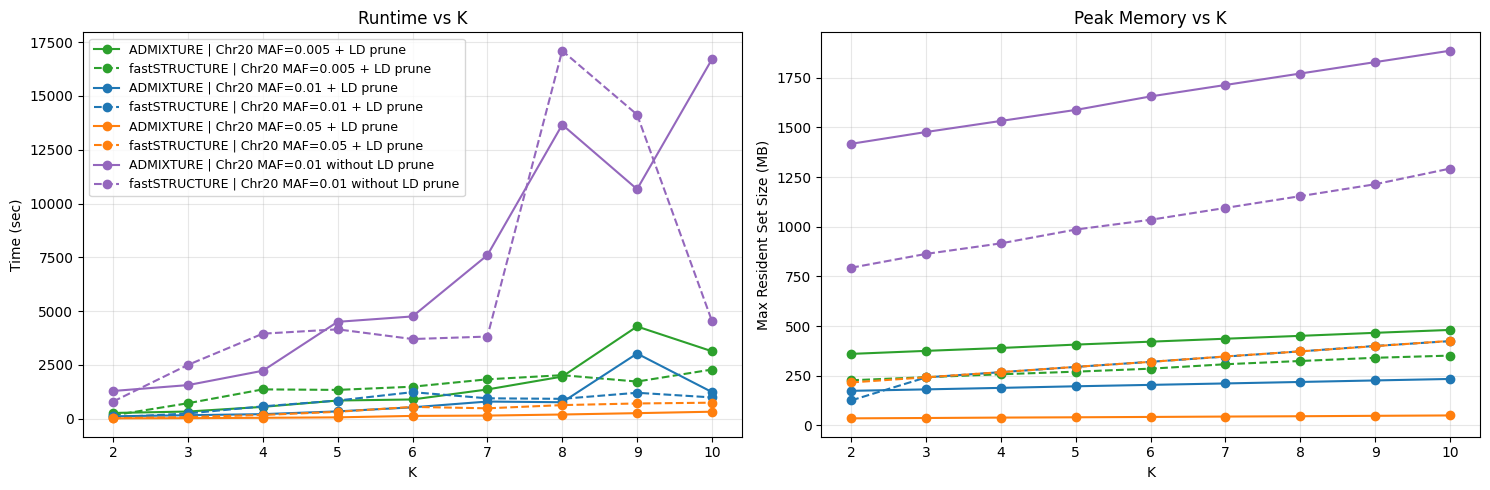

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for experiment in EXPERIMENTS:
    for method_label in ["ADMIXTURE", "fastSTRUCTURE"]:
        group = fit_metrics_ok[
            (fit_metrics_ok["experiment"] == experiment["name"])
            & (fit_metrics_ok["method_label"] == method_label)
        ].sort_values("K_num")
        if group.empty:
            continue
        aligned = (
            group[["K_num", "elapsed_sec", "max_rss_mb"]]
            .drop_duplicates(subset="K_num", keep="last")
            .set_index("K_num")
            .reindex(ALL_K_VALUES)
        )
        curve_label = f"{method_label} | {experiment['label']}"
        axes[0].plot(
            aligned.index,
            aligned["elapsed_sec"],
            marker="o",
            linestyle=METHOD_LINESTYLES[method_label],
            color=experiment["color"],
            label=curve_label,
        )
        axes[1].plot(
            aligned.index,
            aligned["max_rss_mb"],
            marker="o",
            linestyle=METHOD_LINESTYLES[method_label],
            color=experiment["color"],
            label=curve_label,
        )

axes[0].set_title("Runtime vs K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Time (sec)")
axes[0].set_xticks(ALL_K_VALUES)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Peak Memory vs K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Max Resident Set Size (MB)")
axes[1].set_xticks(ALL_K_VALUES)
axes[1].grid(True, alpha=0.3)

axes[0].legend(fontsize=9)

plt.tight_layout()
plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)
fig.savefig(plots_dir / "runtime_memory_vs_k.pdf", bbox_inches="tight")
fig.savefig(plots_dir / "runtime_memory_vs_k.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Check Peak Memory vs K: which two experiments are closest (overlapping lines on Memory plot)
mem = (
    fit_metrics_ok[fit_metrics_ok["method_label"] == "fastSTRUCTURE"]
    .groupby(["experiment_label", "K_num"], as_index=False)["max_rss_mb"]
    .max()
)
mem_pivot = mem.pivot(index="K_num", columns="experiment_label", values="max_rss_mb").sort_index()
print("Peak Memory (MB) by K and experiment (fastSTRUCTURE):")
display(mem_pivot)

# Pairwise max absolute difference in max_rss_mb across K
labels = mem_pivot.columns.tolist()
pairs = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        a, b = labels[i], labels[j]
        diff = (mem_pivot[a] - mem_pivot[b]).abs()
        pairs.append((a, b, diff.max(), diff.idxmax()))
pairs.sort(key=lambda x: x[2])
print("\nPair with smallest max difference (most overlapping on Memory plot):")
a, b, max_diff, k_at_max = pairs[0]
print(f"  {a}")
print(f"  vs {b}")
print(f"  max |diff| = {max_diff:.2f} MB at K={k_at_max}")
if max_diff < 50:
    print("  => Lines are expected to look nearly overlapping (data-driven).")

Peak Memory (MB) by K and experiment (fastSTRUCTURE):


experiment_label,Chr20 MAF=0.005 + LD prune,Chr20 MAF=0.01 + LD prune,Chr20 MAF=0.01 without LD prune,Chr20 MAF=0.05 + LD prune
K_num,,,,
2,227.335938,125.925781,793.625000,216.402344
3,242.898438,241.808594,863.253906,242.187500
4,257.503906,268.121094,916.253906,268.097656
5,270.609375,294.585938,985.878906,294.789062
6,285.671875,320.285156,1034.988281,320.046875
7,308.015625,346.476562,1094.664062,347.304688
8,324.308594,372.773438,1153.960938,372.675781
9,340.453125,400.050781,1213.835938,398.996094
10,351.464844,424.363281,1292.632812,425.378906



Pair with smallest max difference (most overlapping on Memory plot):
  Chr20 MAF=0.005 + LD prune
  vs Chr20 MAF=0.05 + LD prune
  max |diff| = 73.91 MB at K=10


## Qualitative Comparison on Global Ancestry Inference Results

Combined membership plot saved to: plots/special_chr20_maf001_pruned_admixture_combined_membership_panels.png


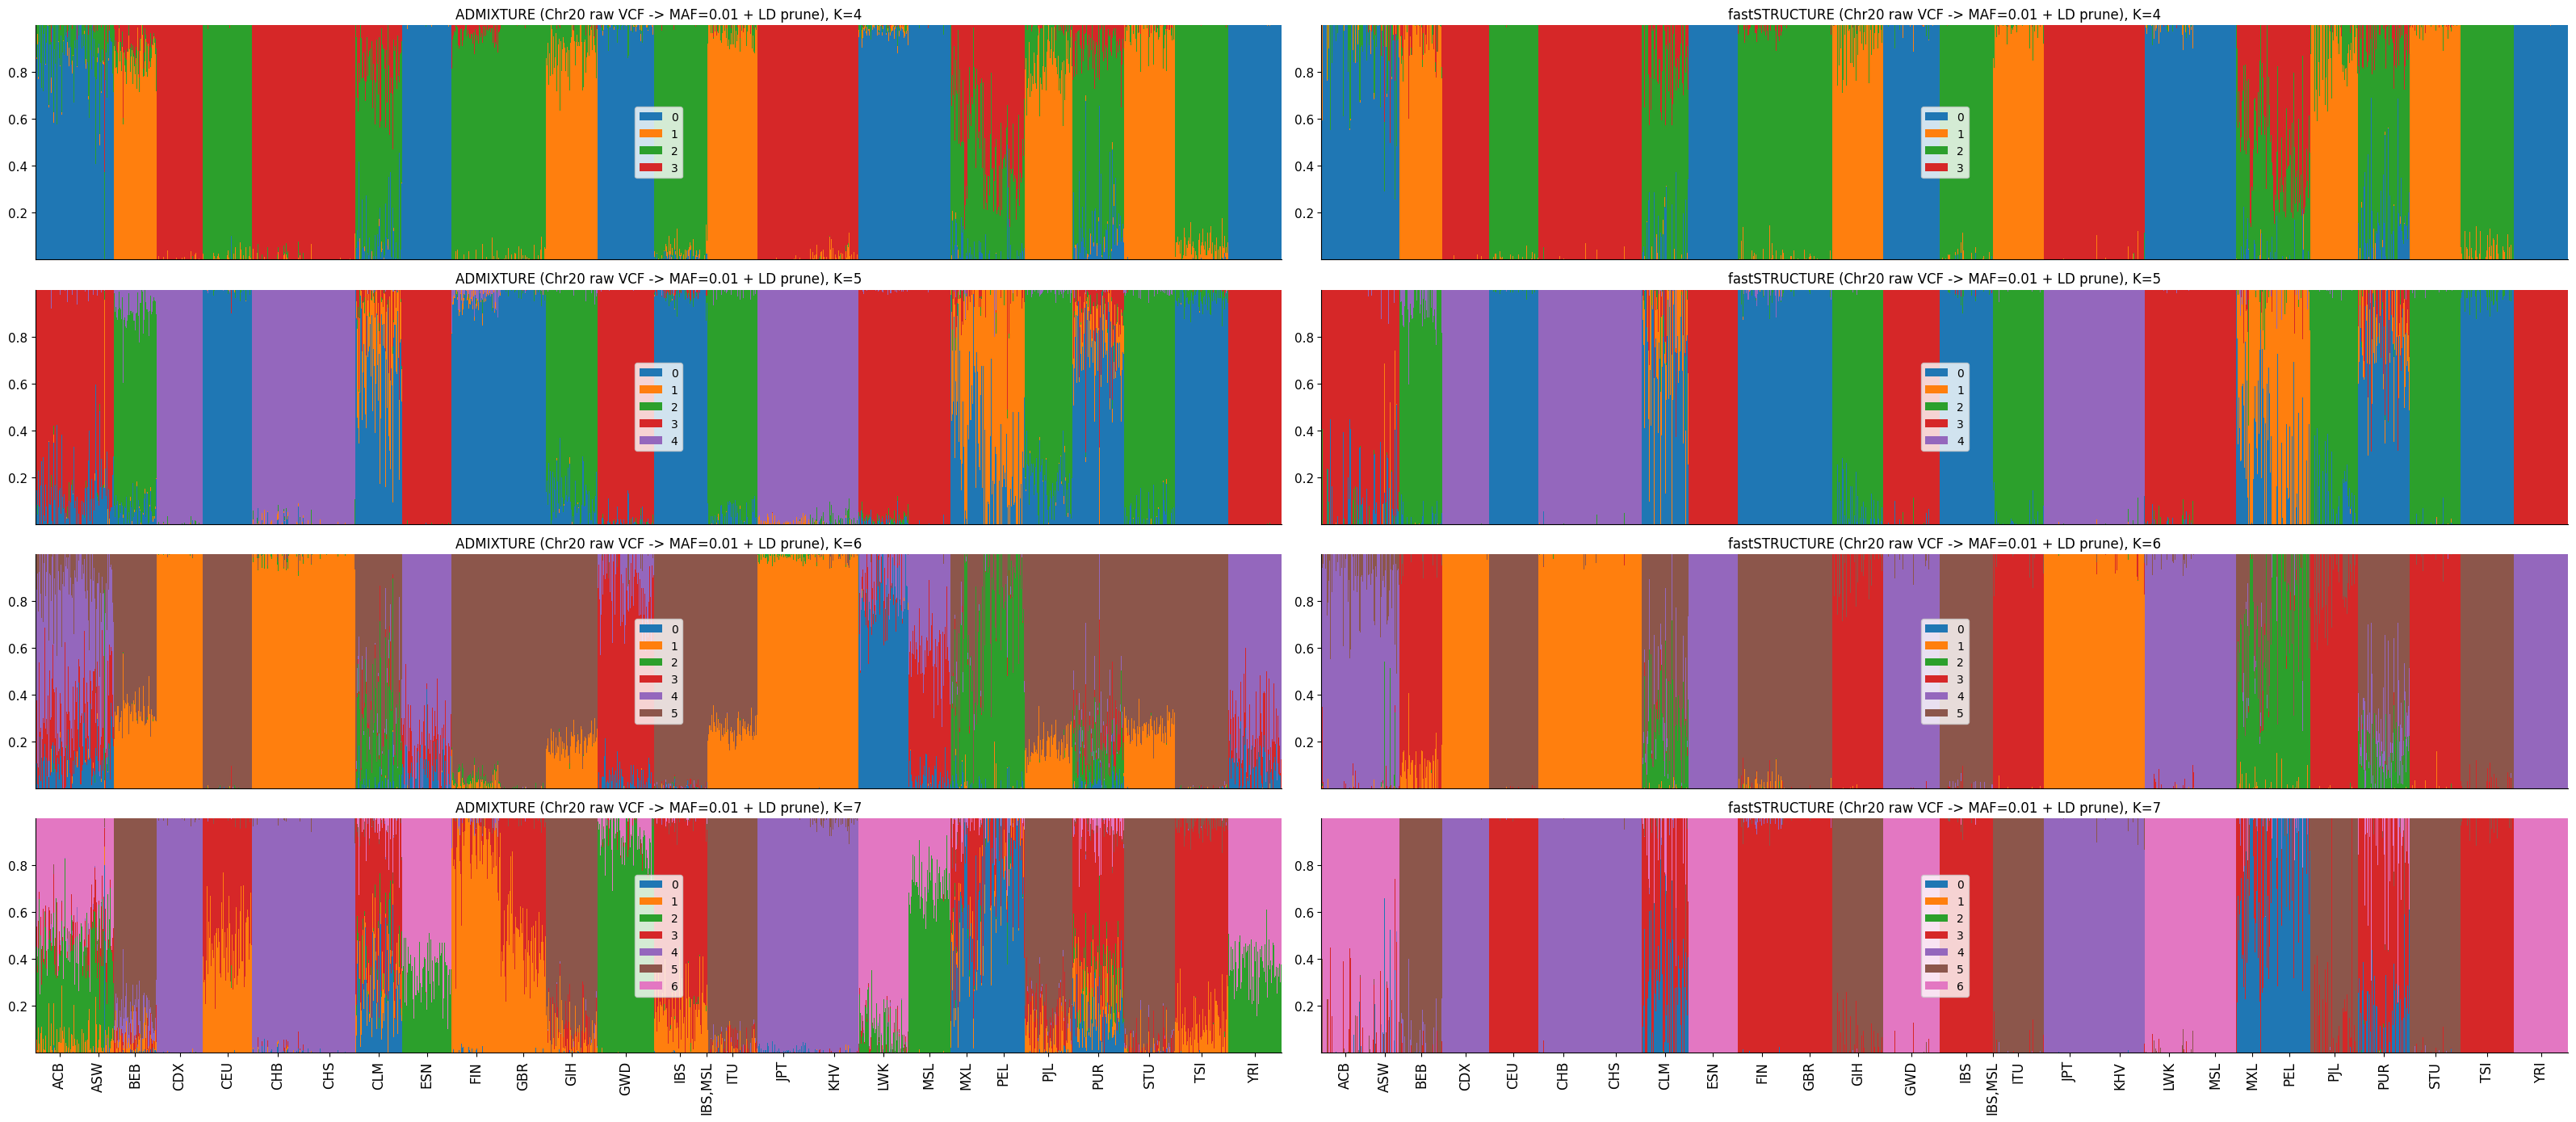

Combined membership plot saved to: plots/special_chr20_maf0005_pruned_admixture_combined_membership_panels.png


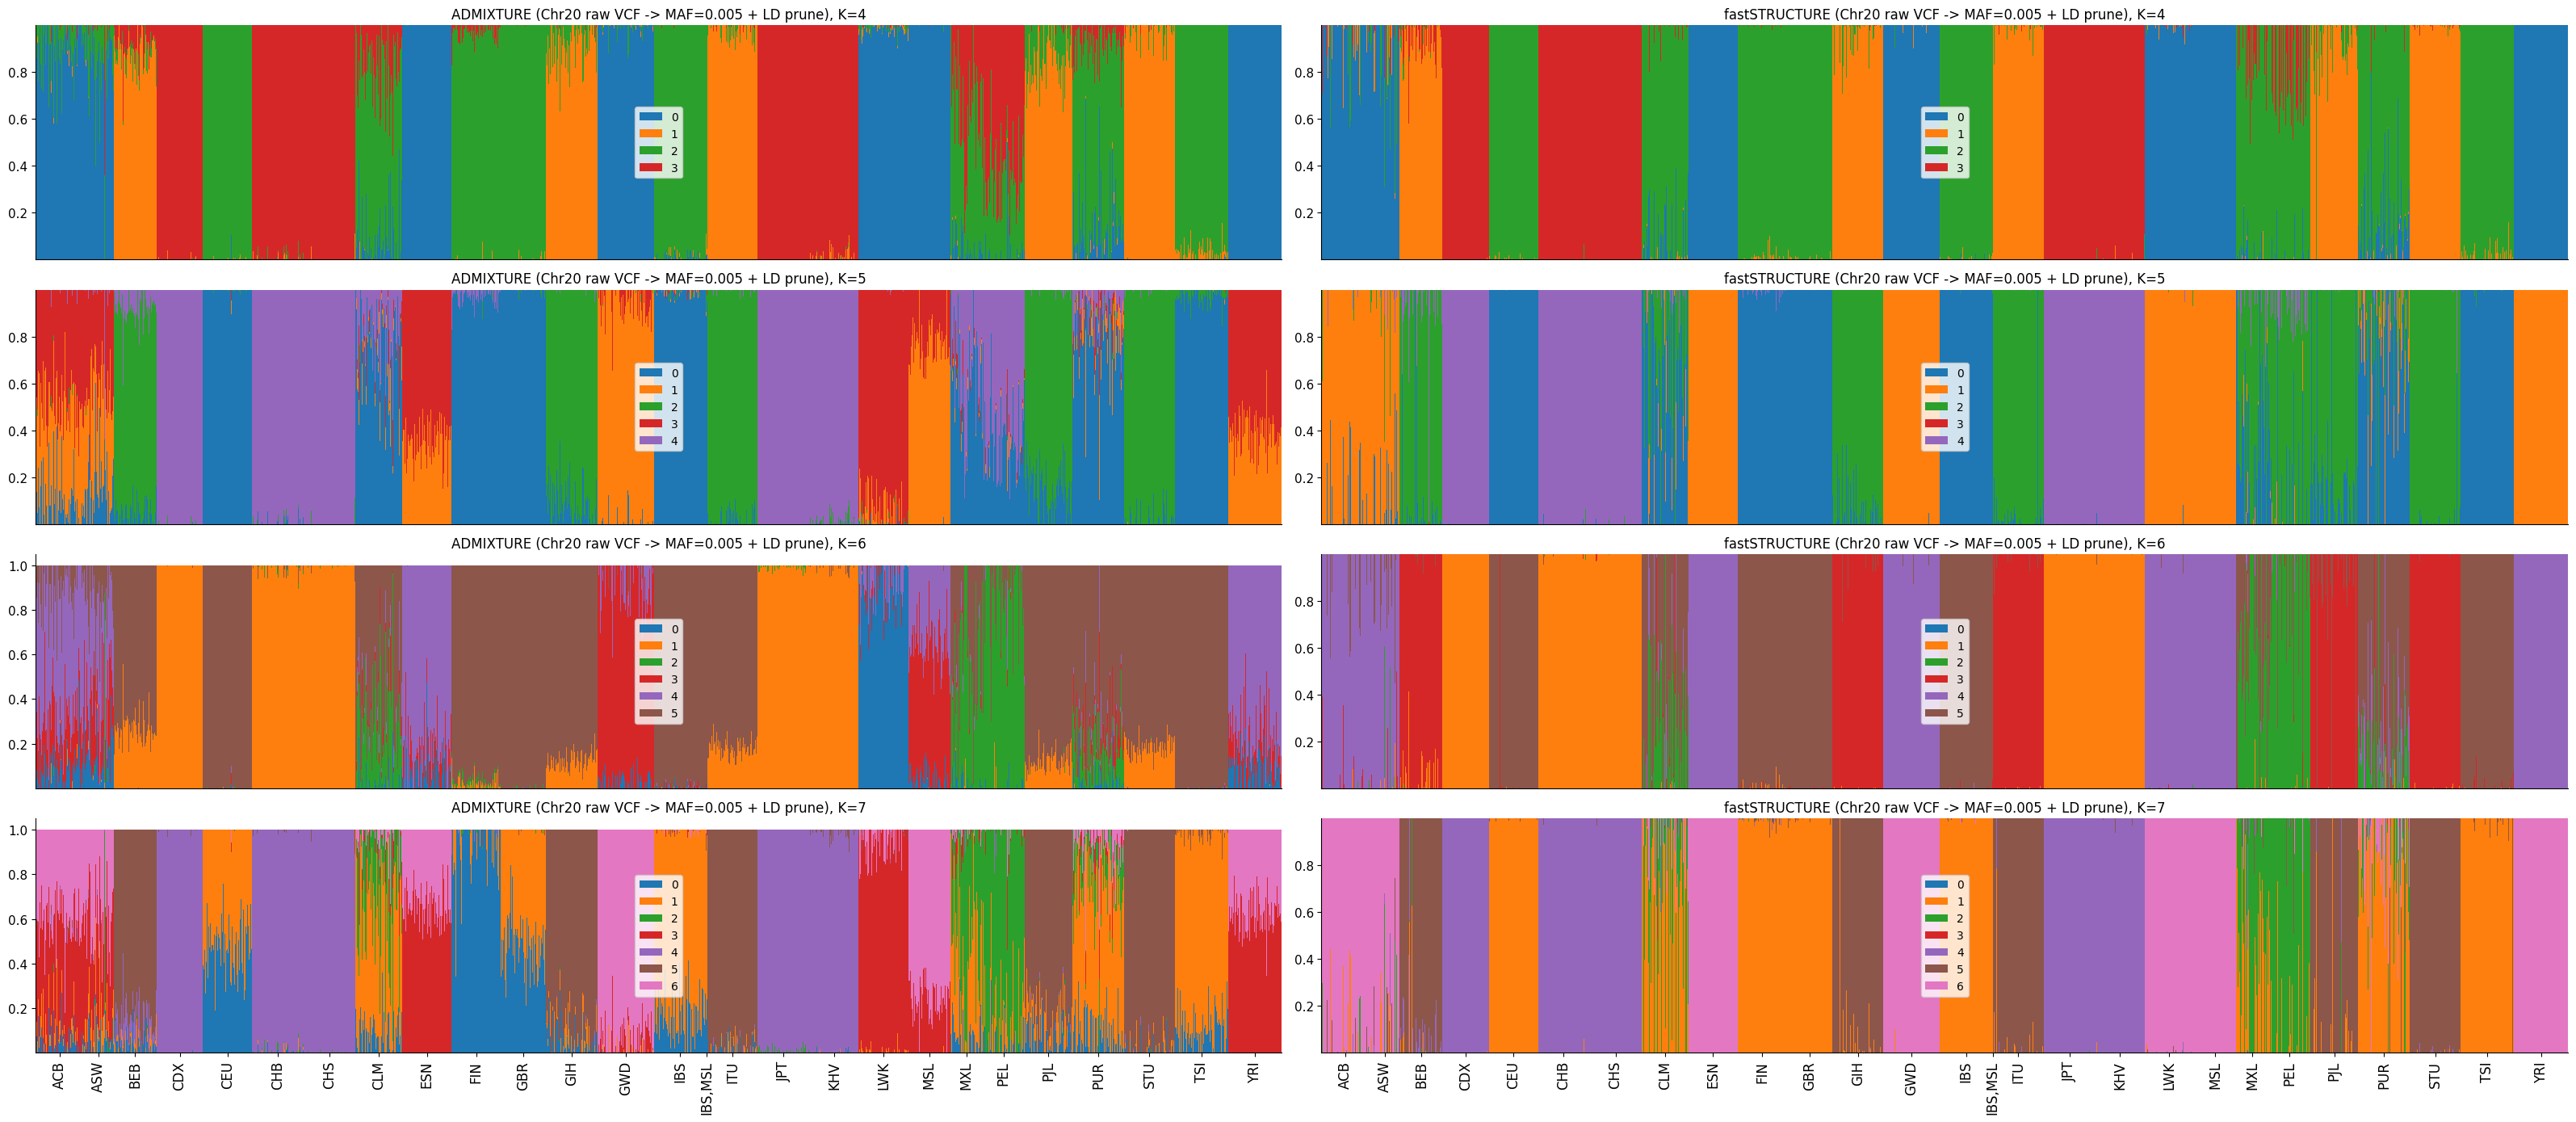

Combined membership plot saved to: plots/special_chr20_maf005_pruned_admixture_combined_membership_panels.png


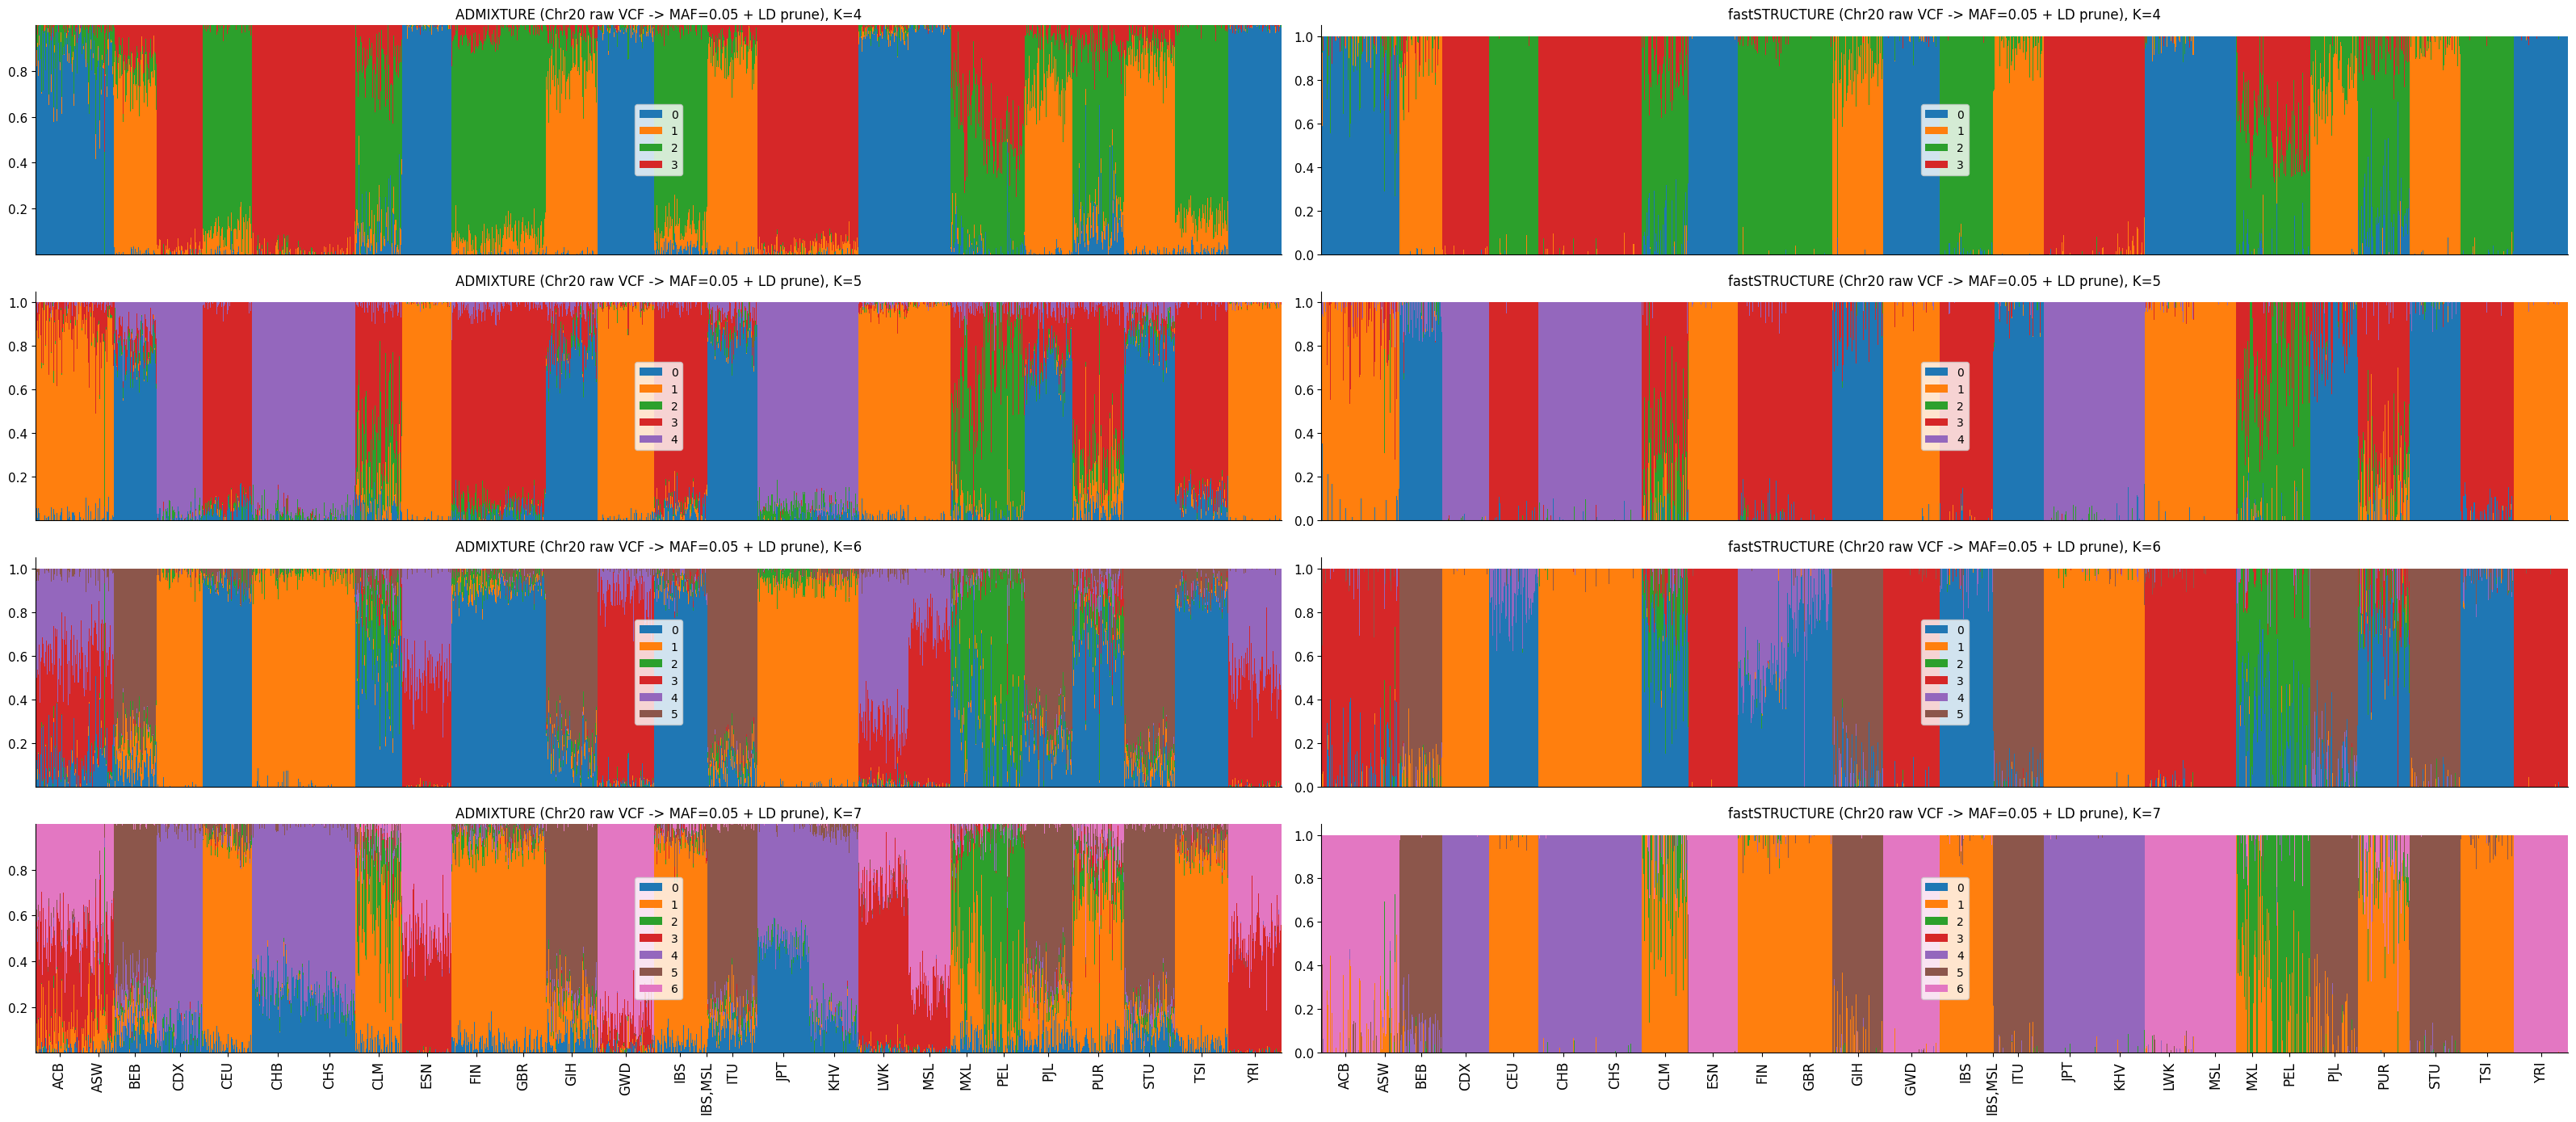

Combined membership plot saved to: plots/special_chr20_maf001_no_ld_admixture_combined_membership_panels.png


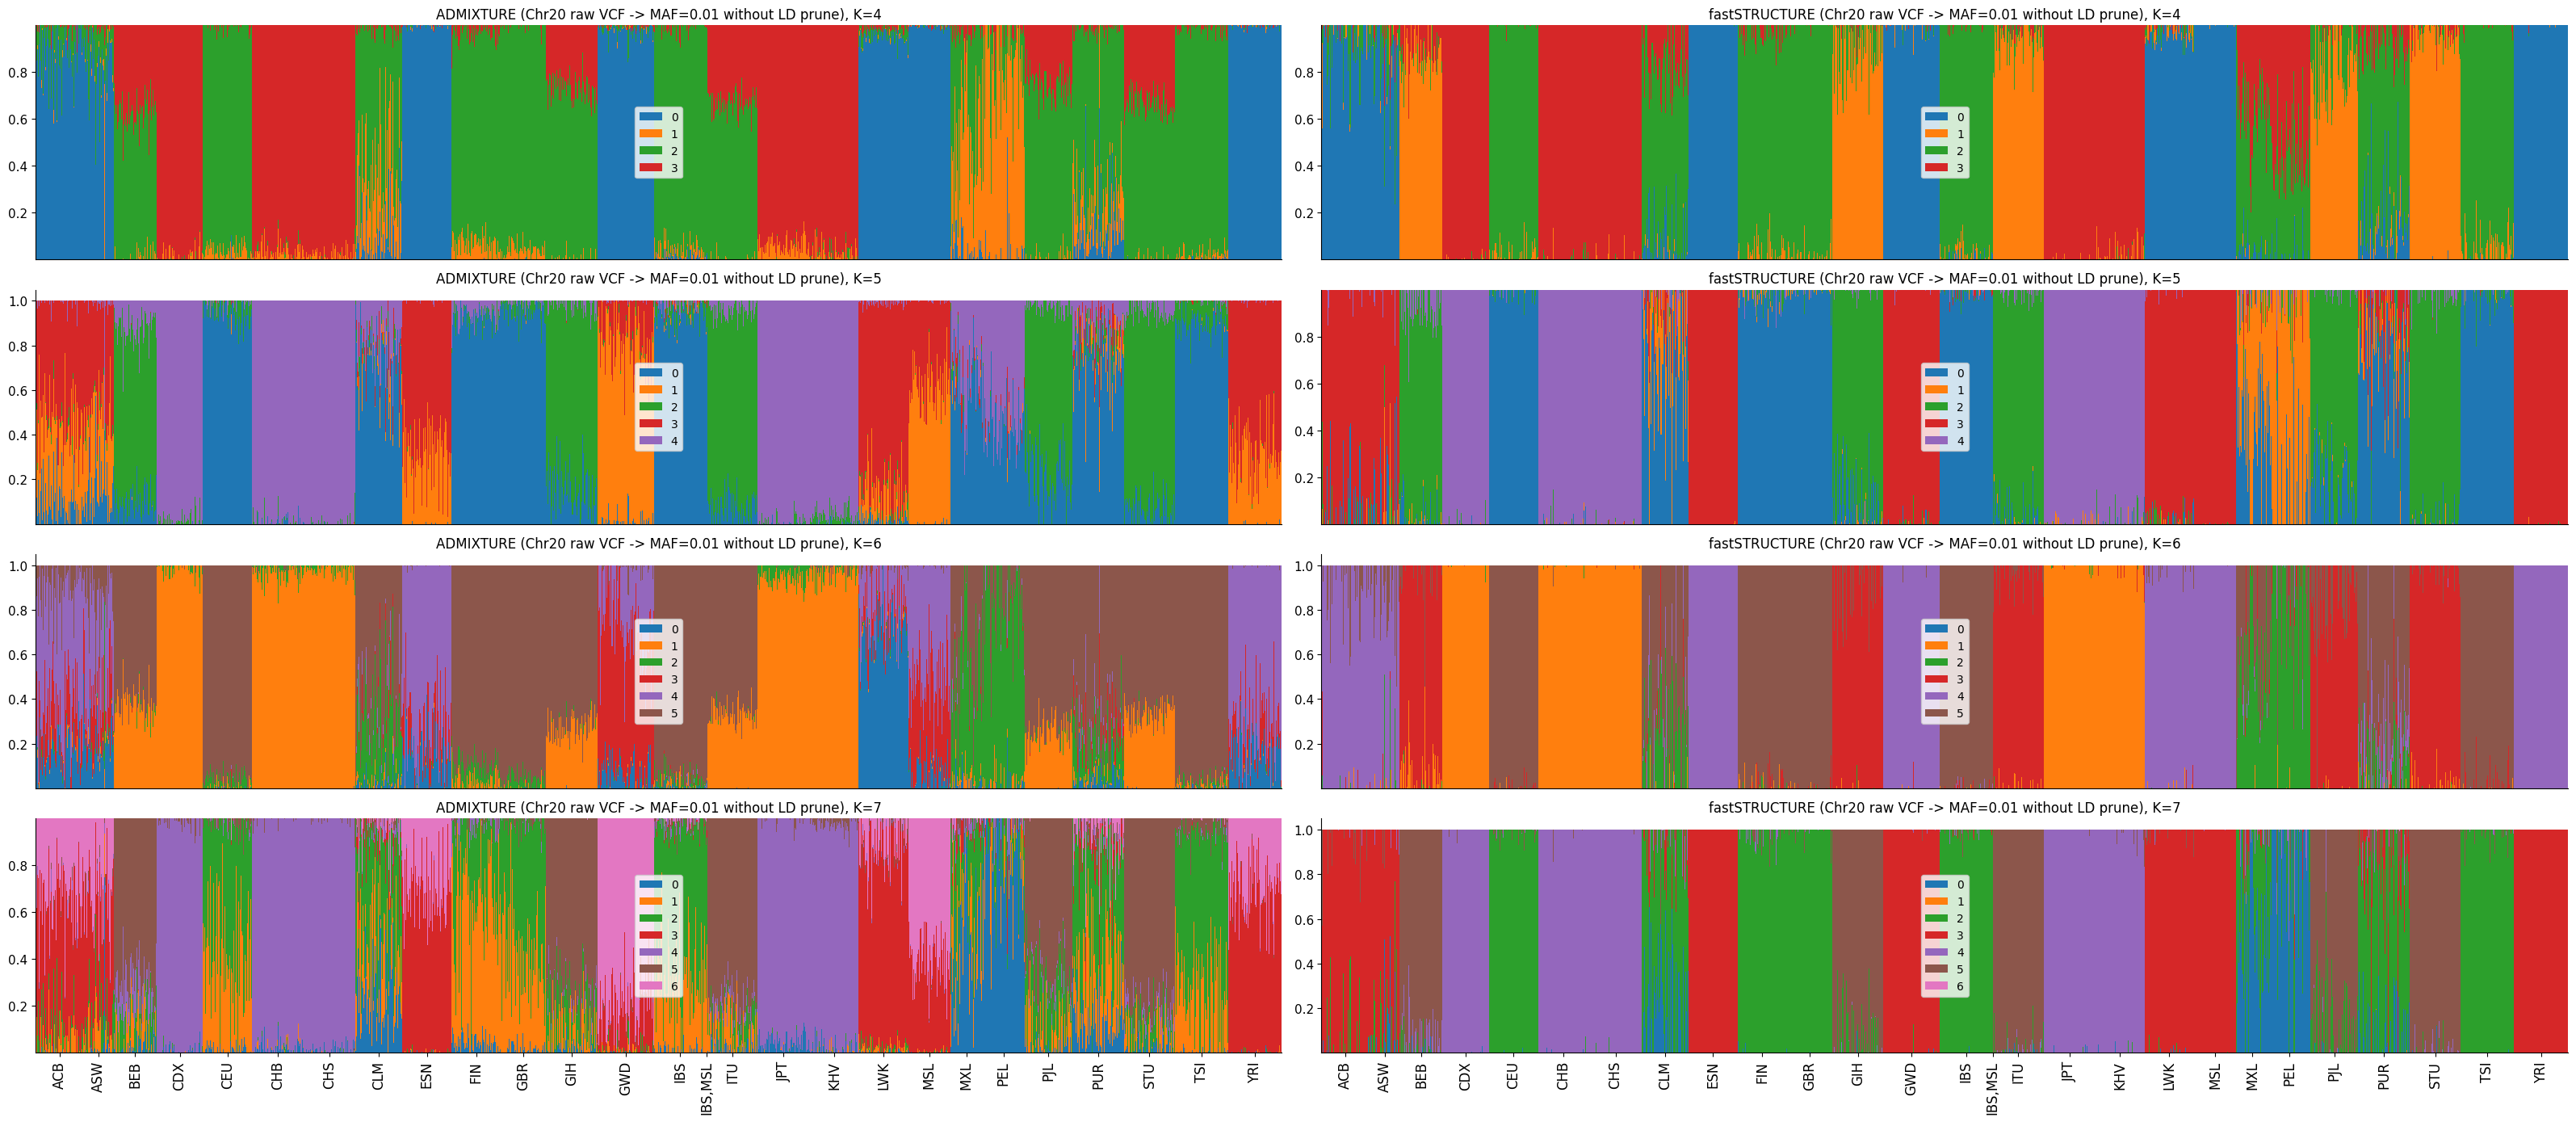

In [9]:
for spec in SPECIAL_EXPERIMENT_SPECS:
    if spec["name"] == "chr1_maf0005_pruned":
        continue
    result = SPECIAL_RESULTS[spec["name"]]
    dataset_name = Path(result["dataset_prefix"]).name
    admixture_template = f"{result['admixture_out_dir']}/{dataset_name}.{{K}}.Q"
    plot_combined_membership_panels(
        fam_path=plink_file(result["dataset_prefix"], ".fam"),
        panels_config=[
            {
                "data_path_template": admixture_template,
                "title_prefix": f"ADMIXTURE ({result['title']})",
            },
            {
                "data_path_template": f"{result['structure_out_dir']}/{result['structure_prefix']}_ALL/fS_run_K.{{K}}.meanQ",
                "title_prefix": f"fastSTRUCTURE ({result['title']})",
                "reference_data_path_template": admixture_template,
            },
        ],
    )


## Quantitative Comparison on Global Ancestry Inference Results


The next two figures mirror the K-value plotting idea from setting 1, split by method. Each method gets one figure with four curves.

In [10]:
def load_admixture_cv(experiment: dict) -> pd.DataFrame:
    cv_path = experiment["admixture_dir"] / "cv_results.txt"
    pairs = []
    for line in cv_path.read_text().strip().splitlines():
        k_str, cv_str = line.split()
        pairs.append((int(k_str), float(cv_str)))
    frame = pd.DataFrame(pairs, columns=["K", "score"])
    frame["experiment"] = experiment["name"]
    frame["experiment_label"] = experiment["label"]
    return frame.sort_values("K")


def extract_marginal_likelihood(log_path: Path) -> float:
    match = re.search(
        r"Marginal Likelihood =\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
        log_path.read_text(),
    )
    if match is None:
        raise ValueError(f"Cannot find marginal likelihood in {log_path}")
    return float(match.group(1))


def load_faststructure_ml(experiment: dict) -> pd.DataFrame:
    result_dir = experiment["structure_dir"] / f"{experiment['structure_prefix']}_ALL"
    rows = []
    for meanq_path in sorted(result_dir.glob("fS_run_K.*.meanQ")):
        match = re.search(r"K\.([0-9]+)\.meanQ$", meanq_path.name)
        if match is None:
            continue
        k_value = int(match.group(1))
        log_path = result_dir / f"fS_run_K.{k_value}.log"
        rows.append(
            {
                "K": k_value,
                "score": extract_marginal_likelihood(log_path),
                "experiment": experiment["name"],
                "experiment_label": experiment["label"],
            }
        )
    return pd.DataFrame(rows).sort_values("K")


admix_k_metrics = pd.concat([load_admixture_cv(experiment) for experiment in EXPERIMENTS], ignore_index=True)
faststructure_k_metrics = pd.concat(
    [load_faststructure_ml(experiment) for experiment in EXPERIMENTS],
    ignore_index=True,
)
from IPython.display import display
print("ADMIXTURE CV (head):")
display(admix_k_metrics.head())
print("fastSTRUCTURE Marginal Likelihood (head):")
display(faststructure_k_metrics.head())

ADMIXTURE CV (head):


,K,score,experiment,experiment_label
0,2,0.15339,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune
1,3,0.14575,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune
2,4,0.14318,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune
3,5,0.14308,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune
4,6,0.14380,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune


fastSTRUCTURE Marginal Likelihood (head):


,K,score,experiment,experiment_label
0,2,-0.254722,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune
1,3,-0.249310,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune
2,4,-0.248825,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune
3,5,-0.249184,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune
4,6,-0.248735,chr20_maf0005_pruned,Chr20 MAF=0.005 + LD prune


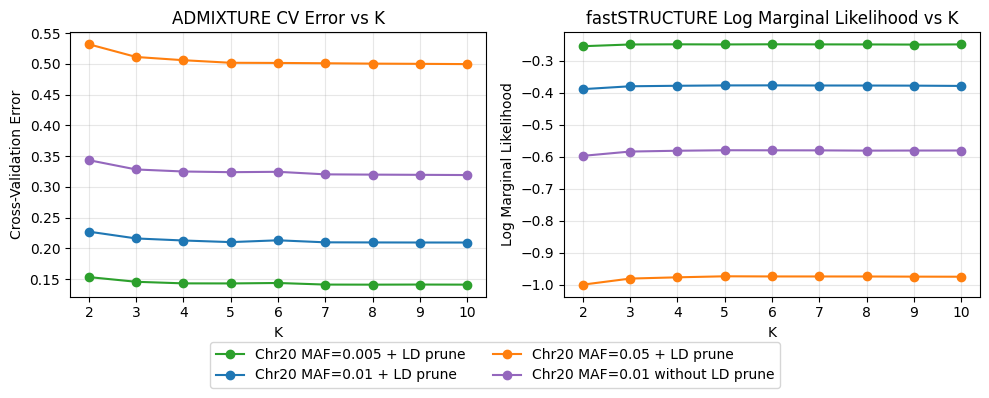

In [ ]:
# One figure with two subplots; shared legend below so it does not overlap the plots.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
handles = []

for experiment in EXPERIMENTS:
    group = admix_k_metrics[admix_k_metrics["experiment"] == experiment["name"]].sort_values("K")
    aligned = group.drop_duplicates(subset="K", keep="last").set_index("K").reindex(ALL_K_VALUES)
    line, = axes[0].plot(aligned.index, aligned["score"], marker="o", color=experiment["color"], label=experiment["label"])
    handles.append(line)
axes[0].set_title("ADMIXTURE CV Error vs K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Cross-Validation Error")
axes[0].set_xticks(ALL_K_VALUES)
axes[0].grid(True, alpha=0.3)

for experiment in EXPERIMENTS:
    group = faststructure_k_metrics[faststructure_k_metrics["experiment"] == experiment["name"]].sort_values("K")
    aligned = group.drop_duplicates(subset="K", keep="last").set_index("K").reindex(ALL_K_VALUES)
    axes[1].plot(aligned.index, aligned["score"], marker="o", color=experiment["color"])
axes[1].set_title("fastSTRUCTURE Log Marginal Likelihood vs K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Log Marginal Likelihood")
axes[1].set_xticks(ALL_K_VALUES)
axes[1].grid(True, alpha=0.3)

fig.legend(handles, [e["label"] for e in EXPERIMENTS], loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=True)
plt.tight_layout(rect=(0, 0.1, 1, 1))
plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)
fig.savefig(plots_dir / "cv_ml_vs_k.pdf", bbox_inches="tight")
fig.savefig(plots_dir / "cv_ml_vs_k.png", dpi=300, bbox_inches="tight")
plt.show()